In [6]:
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds
import numpy as np

# --- 1. Definizione dei percorsi ---
csv_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\OnStoveThesis\thesis\script_nostri\archived script galga\dataset_first_step\support_files\fob_per_kg.csv"
output_tif_path = r"C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\fob_per_kg.tif"

# --- 2. Caricamento dei dati ---
df = pd.read_csv(csv_path)
df.columns.values[0] = 'iso3'

# Carica i confini dei paesi a scala 1:10 milioni
url_natural_earth_10m = "https://naciscdn.org/naturalearth/10m/cultural/ne_10m_admin_0_countries.zip"
world = gpd.read_file(url_natural_earth_10m)

# --- 3. Unione e Filtraggio ---
merged = world.merge(df, left_on='ISO_A3', right_on='iso3', how='inner')

# --- 4. Sostituzione dei valori -1 con la media dei confinanti ---
merged['fob_final'] = merged['fob_per_kg'].astype(float)
nazioni_mancanti = merged[merged['fob_final'] == -1].index

for idx in nazioni_mancanti:
    geometria_nazione = merged.loc[idx, 'geometry']
    confinanti = merged[merged.geometry.touches(geometria_nazione) | merged.geometry.intersects(geometria_nazione)]
    
    valori_validi = confinanti[(confinanti.index != idx) & (confinanti['fob_per_kg'] != -1)]['fob_per_kg']
    
    if not valori_validi.empty:
        media_confinanti = valori_validi.mean()
        merged.loc[idx, 'fob_final'] = media_confinanti
        print(f"Sostituito -1 per {merged.loc[idx, 'ISO_A3']} con {media_confinanti:.4f}")
    else:
        print(f"Attenzione: Nessun confinante valido con dati per {merged.loc[idx, 'ISO_A3']}. Il valore resta -1.")

# --- 5. Creazione del Raster tramite Rasterio ---
print("Generazione del raster in corso ad alta risoluzione spaziale (0.01 gradi)...")

res = 0.01
minx, miny, maxx, maxy = merged.total_bounds
width = int(np.ceil((maxx - minx) / res))
height = int(np.ceil((maxy - miny) / res))
transform = from_bounds(minx, miny, maxx, maxy, width, height)

shapes = ((geom, value) for geom, value in zip(merged.geometry, merged['fob_final']))

raster_array = rasterize(
    shapes=shapes,
    out_shape=(height, width),
    transform=transform,
    fill=-9999,
    dtype='float32'
)

# --- 6. Salvataggio del file GeoTIFF ---
with rasterio.open(
    output_tif_path,
    'w',
    driver='GTiff',
    height=height,
    width=width,
    count=1,
    dtype=raster_array.dtype,
    crs=merged.crs,
    transform=transform,
    nodata=-9999
) as dst:
    dst.write(raster_array, 1)

print(f"File salvato con successo in: {output_tif_path}")

Sostituito -1 per SLE con 1.1434
Sostituito -1 per AGO con 0.7905
Generazione del raster in corso ad alta risoluzione spaziale (0.01 gradi)...
File salvato con successo in: C:\Users\Fra\OneDrive - Politecnico di Milano\File di Mattia Cinchetti - Thesis_onstoveM&F\repo_2jun\OnStoveThesis\thesis\script_nostri\dataset\fob_per_kg.tif


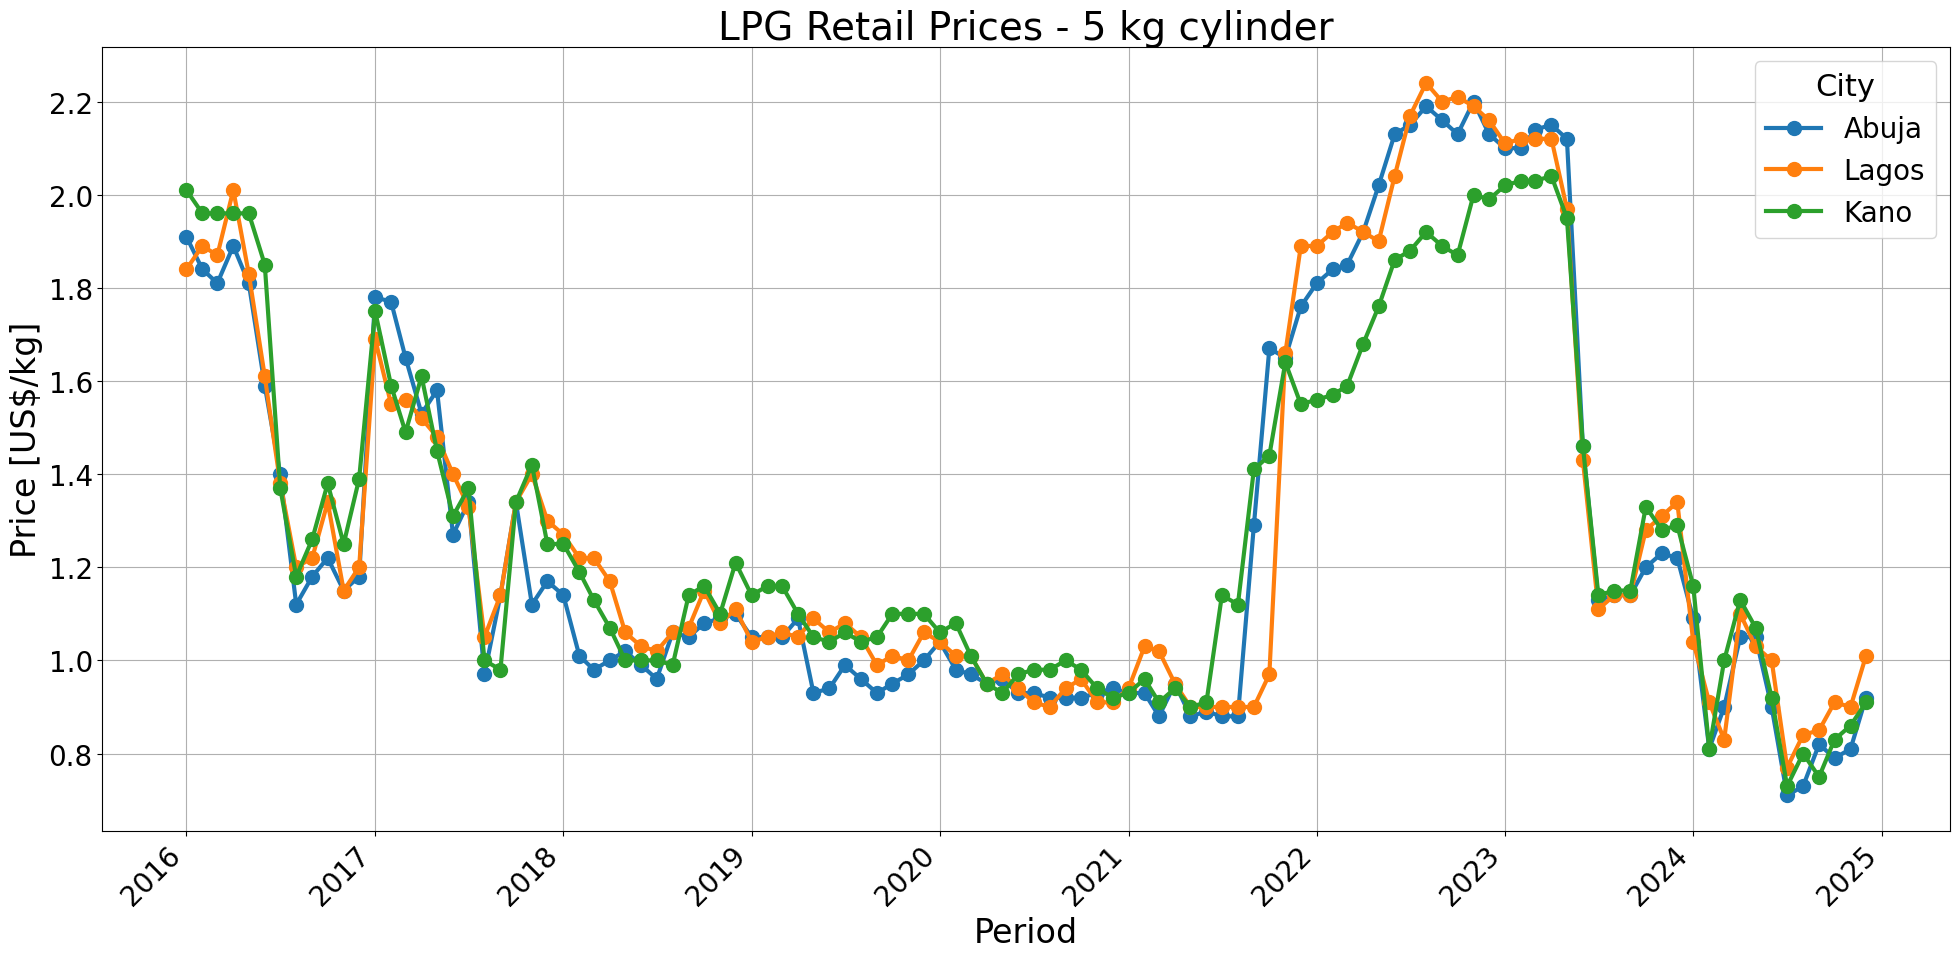

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Impostazione globale della dimensione del testo (il default è 10, impostato a 20)
plt.rcParams.update({'font.size': 20})

# Percorso del file
percorso_file = r"C:\Users\Fra\Desktop\prezzi lpg lagos abuja.xlsx"

# Lettura e preparazione dei dati
df = pd.read_excel(percorso_file)
df.columns.values[0] = 'Citta'
df.columns.values[1] = 'Unita'
df = df.drop(columns=['Unita'])
df = df.set_index('Citta')

# Trasposizione per avere le date sull'asse X
df_trasposto = df.T

# Creazione del grafico a linee con spessore e marker proporzionati
df_trasposto.plot(kind='line', marker='o', figsize=(20, 10), linewidth=3, markersize=10)

# Configurazione del grafico con font ingranditi
plt.title('LPG Retail Prices - 5 kg cylinder', fontsize=28)
plt.ylabel('Price [US$/kg]', fontsize=24)
plt.xlabel('Period', fontsize=24)
plt.xticks(rotation=45, fontsize=20)
plt.yticks(fontsize=20)
plt.legend(title='City', fontsize=20, title_fontsize=22)
plt.grid(True)
plt.tight_layout()

# Mostra il grafico
plt.show()